In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import openpyxl

# Import Class
from pathlib import Path

In [2]:
# Set Path to current working directoryu
cwd = Path.cwd()

# Set filesystem paths
ROOT = cwd.parent if cwd.name == "notebooks" else cwd

In [3]:
# Test ROOT
ROOT

PosixPath('/home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1')

In [4]:
# Create DATA_RAW
DATA_RAW = ROOT / "data" / "raw"

In [5]:
# Test DATA_RAW
DATA_RAW

PosixPath('/home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1/data/raw')

In [6]:
# Create DATA_PROCESSED
DATA_PROCESSED = ROOT / "data" / "processed"

In [7]:
# Create FIGURES
FIGURES = ROOT / "figures"

In [8]:
# Test all paths
ROOT, DATA_PROCESSED, FIGURES

(PosixPath('/home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1'),
 PosixPath('/home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1/data/processed'),
 PosixPath('/home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1/figures'))

In [9]:
# Set scope in years of available data
YEAR_MIN = 2015

In [10]:
YEAR_MAX = 2023

In [11]:
# Test variables
YEAR_MIN, YEAR_MAX

(2015, 2023)

In [12]:
# Verify all paths
print("ROOT:", ROOT)
print("RAW DATA:", DATA_RAW)
print("PROCESSED DATA:", DATA_PROCESSED)
print("FIGURES:", FIGURES)

ROOT: /home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1
RAW DATA: /home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1/data/raw
PROCESSED DATA: /home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1/data/processed
FIGURES: /home/ggirelli/Documents/DataAnalysis/Projects/Capstone_1/figures


In [13]:
RAW_DEMOGRAPHIC_ASPECTS_FILE = DATA_RAW / "Demographic-aspects-2023.xlsx"

In [14]:
# Set variable for wide format
df_wide = pd.read_excel(RAW_DEMOGRAPHIC_ASPECTS_FILE, header=1)

In [15]:
# Create "if statement" to test for errors
if not RAW_DEMOGRAPHIC_ASPECTS_FILE.exists():
    raise FileNotFoundError

In [16]:
df_wide.columns
df_wide.describe

<bound method NDFrame.describe of       Key Demographic aspects      Unit      2015      2016      2017  \
0                       Males  Absolute   51309.0   51462.0   51399.0   
1                     Females  Absolute   57326.0   57357.0   57253.0   
2            Total population  Absolute  108635.0  108818.0  108651.0   
3                   Sex ratio       NaN      89.5      89.7      89.8   
4           Pop. per km2 land  Absolute     604.0     605.0     604.0   
5   Pop. 14 years and younger         %      18.9      18.7      18.6   
6     Pop. 60 years and older         %      18.7      19.4      20.1   
7                 Average age       NaN       NaN       NaN       NaN   
8                       Males     Years      37.5      37.8      38.1   
9                     Females     Years      40.1      40.4      40.7   
10                      Total     Years      38.9      39.2      39.5   
11              Net migration  Absolute     900.0    -293.0    -698.0   

        2018    

In [17]:
# Filter the data into our two groups
males = df_wide[df_wide["Key Demographic aspects"] == "Males"]
females = df_wide[df_wide["Key Demographic aspects"] == "Females"]


In [18]:
# Calculate the yearly change (slicing 2015 to 2023)
# Using.diff(axis=1) to subtract each year from the previous one
yearly_change_males = males.loc[:, 2015:2023].diff(axis=1)
yearly_change_females = females.loc[:, 2015:2023].diff(axis=1)

In [19]:
# Combine them into one comparison table
comparison_df = pd.concat([yearly_change_males, yearly_change_females], keys=["Males", "Females"])

In [20]:
# Clean up: drop the extra index level and fill the 2015 NaNs with 0
comparison_df = comparison_df.droplevel(1).fillna(0)

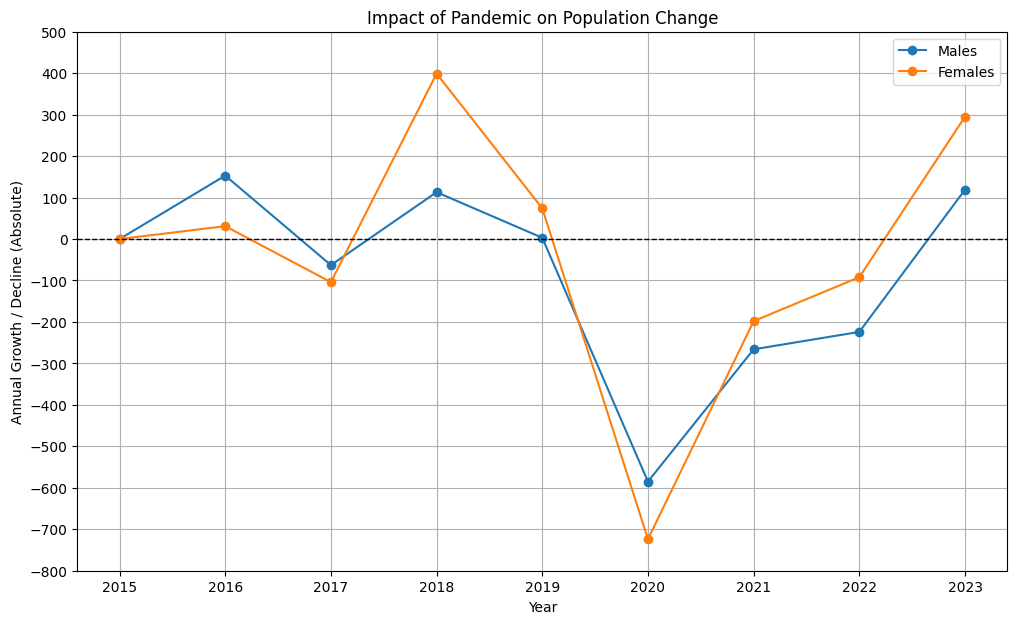

In [21]:
# Create the plot
comparison_df.T.plot(kind="line", marker="o", grid=True, figsize=(12, 7), title="Impact of Pandemic on Population Change")

# Add specific y-axis ticks (from -800 to 500, every 100)
plt.yticks(np.arange(-800, 501, 100))

# Add the labels
plt.ylabel("Annual Growth / Decline (Absolute)")
plt.xlabel("Year")

# Add a horizontal line at 0 to highlight the "Recovery" threshold
plt.axhline(0, color="black", linestyle="--", linewidth=1)

plt.savefig("Demographic_Changes_Aruba-2015-2023")
plt.show()